In [2]:
!pip install shap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.8 MB/s eta 0:00:00


In [3]:
!wget -q https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv -O pima.csv

In [4]:
import pandas as pd

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('pima.csv', names=cols)
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
import numpy as np

# These columns cannot biologically be zero
zero_not_allowed = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

# Replace 0 with NaN
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)

# Check how many missing values we now have
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Verify no more nulls
print(df_imputed.isnull().sum())


df_imputed.describe()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.598177,72.371354,29.114583,153.180208,32.427344,0.471876,33.240885,0.348958
std,3.369578,30.496543,12.206417,9.424100,98.385308,6.886588,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,23.000000,87.900000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,133.700000,32.090000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,35.000000,190.150000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# Feature Engineering
df_imputed['BMI_Age'] = df_imputed['BMI'] * df_imputed['Age']
df_imputed['Glucose_Insulin_Ratio'] = df_imputed['Glucose'] / df_imputed['Insulin']
df_imputed['Glucose_BMI'] = df_imputed['Glucose'] * df_imputed['BMI']

# Round Outcome back to int
df_imputed['Outcome'] = df_imputed['Outcome'].round().astype(int)

print(df_imputed.shape)
df_imputed.head()

(768, 12)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_Insulin_Ratio,Glucose_BMI
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1,1680.0,0.875740,4972.8
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0,824.6,1.450512,2261.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1,745.6,1.111786,4263.9
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,590.1,0.946809,2500.9
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,1422.3,0.815476,5904.7


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_imputed.drop('Outcome', axis=1)
y = df_imputed['Outcome']

# Split — 80% train, 20% test, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"\nClass balance in train:\n{y_train.value_counts(normalize=True).round(3)}")

Train size: (614, 11)
Test size: (154, 11)

Class balance in train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print(f"{'Model':<25} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 47)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} {scores.mean():.4f}      ±{scores.std():.4f}")

Model                      CV Accuracy      Std
-----------------------------------------------
Logistic Regression       0.7883      ±0.0180
Random Forest             0.7704      ±0.0378
SVM                       0.7769      ±0.0221
XGBoost                   0.7297      ±0.0213


In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Logistic Regression ---
def objective_lr(trial):
    C = trial.suggest_float('C', 0.001, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
    scores = cross_val_score(
        LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42),
        X_train_scaled, y_train, cv=5, scoring='accuracy'
    )
    return scores.mean()

# --- XGBoost ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    scores = cross_val_score(
        XGBClassifier(**params, random_state=42, eval_metric='logloss'),
        X_train_scaled, y_train, cv=5, scoring='accuracy'
    )
    return scores.mean()

# Run both studies
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print("=== Logistic Regression ===")
print(f"Best accuracy: {study_lr.best_value:.4f}")
print(f"Best params: {study_lr.best_params}")

print("\n=== XGBoost ===")
print(f"Best accuracy: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

=== Logistic Regression ===
Best accuracy: 0.7883
Best params: {'C': 1.3020595209575239, 'solver': 'liblinear'}

=== XGBoost ===
Best accuracy: 0.7867
Best params: {'n_estimators': 65, 'max_depth': 2, 'learning_rate': 0.020235420052014463, 'subsample': 0.8399209967736238, 'colsample_bytree': 0.7301197597950347}


=== Final Model Evaluation ===

              precision    recall  f1-score   support

 No Diabetes       0.74      0.81      0.78       100
    Diabetes       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154

ROC-AUC Score: 0.8087


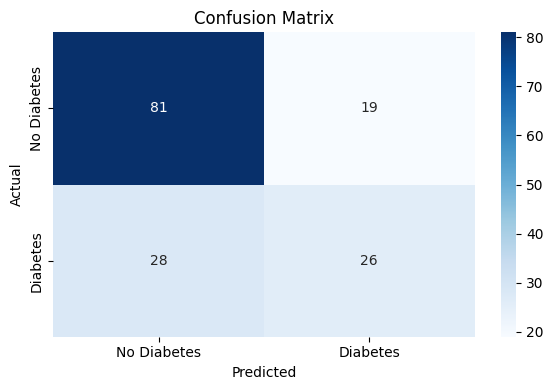

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train final model with best params
final_model = LogisticRegression(
    C=study_lr.best_params['C'],
    solver=study_lr.best_params['solver'],
    max_iter=1000,
    random_state=42
)
final_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=== Final Model Evaluation ===\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

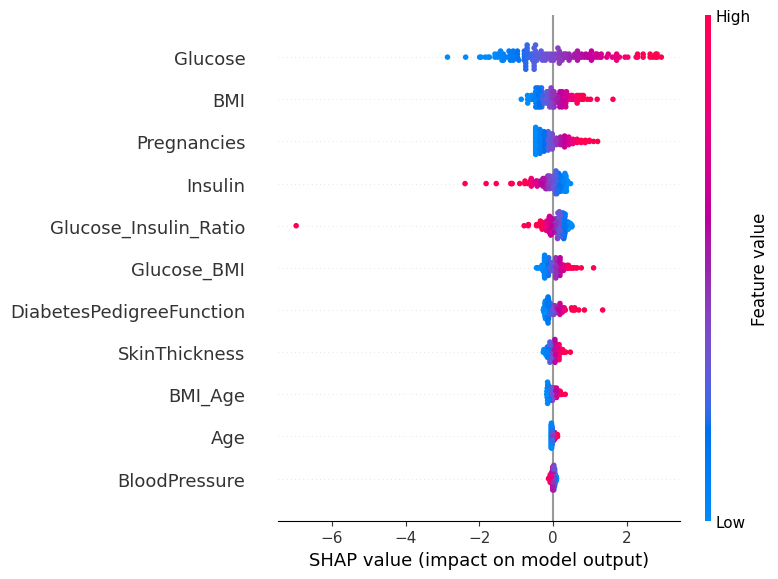

In [13]:
import shap

explainer = shap.LinearExplainer(final_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

In [14]:
import joblib

joblib.dump(final_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved successfully")

Saved successfully
